In [1]:
import MDAnalysis as mda
from numpy import *
import os
from pylab import *
import MDAnalysis.analysis.distances
import MDAnalysis.analysis.rms
from MDAnalysis.analysis import align
import glob
import umap
import scipy.stats
import sklearn
import sklearn.decomposition
import sklearn.preprocessing
import pandas as pd
import seaborn as sns
from MDAnalysis.analysis.hydrogenbonds.hbond_analysis import HydrogenBondAnalysis as HBA

In [2]:
import os

########################################################
#############      FOR NOW EQPOINT IS 0   ##############
########################################################
EQPOINT=0

systemFolders = glob.glob("huNumbering/*t5a*/")

systemgros=[]
systemtprs=[]
systemtrjs=[]
for i in range(len(systemFolders)):
    systemgros.append(sorted(glob.glob(systemFolders[i]+"*.gro")))
    systemtprs.append(sorted(glob.glob(systemFolders[i]+"*.tpr")))
    systemtrjs.append(sorted(glob.glob(systemFolders[i]+"*.xtc")))


    
    
threeColor=["#FE6100","#332288","#882255"]
colourScheme= threeColor
system_names = ["rhT5A","T5A","T5AR332P"]
systems=[]
for i in range(len(systemgros)):
    sub=[]
    for j in range(len(systemgros[i])):
        # When using TPRs, residues are indexed from 1; so we need to add in the first residue, 1 - 1 + first resid=first resid
        #firstres = mda.Universe(systemgros[i][j]).residues.resids[0]-1
        tu = mda.Universe(systemgros[i][j],systemtrjs[i][j])
        #tu.residues.resids +=firstres
                          
        sub.append(tu)
        
    systems.append(sub)


bodys=[]
bodystrings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="(resid 324:349 or resid 378:406 or resid 412:440 or resid 1000:2000)"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []
    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and not ("+combinedLoopString+")"))
        sub2.append("protein and not ("+combinedLoopString+")")
        
    bodys.append(sub)
    bodystrings.append(sub2)
    
    
v1s=[]
v1strings=[]
# rhesus v1 is 326-349
# Human v1 is 324-345
#huloopstring = "resid 324:345"
#rhloopstring = "resid 326:349"
combinedLoopString="resid 324:345"
#system_loop_strings = [rhloopstring,huloopstring,huloopstring]
for i in range(len(systems)):
    sub = []
    sub2 = []

    for j in range(len(systems[i])):
        sub.append(systems[i][j].select_atoms("protein and "+combinedLoopString))
        sub2.append("protein and "+combinedLoopString)

        
    v1s.append(sub)        
    v1strings.append(sub2)
                   

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [3]:
def getRgs(systems,datasets,selection_strings):
    allrgs=[]
    rgs=[]
    stderrs=[]
    for i in range(len(datasets)):
        subrgs=[]
        for j in range(len(datasets[i])):
            rg=[]
            for ts in systems[i][j].trajectory: 
                rg.append((systems[i][j].trajectory.time, systems[i][j].select_atoms(selection_strings[i][j]).radius_of_gyration())[1])
            subrgs.append(rg)
        allrgs.append(subrgs)

    return allrgs

all_body_rgs = getRgs(systems,bodys,bodystrings)

systemrgs=[]
for i in range(len(all_body_rgs)):
    trjrgs=[]
    for j in range(len(all_body_rgs[i])):
        trjrgs.append(mean(all_body_rgs[i][j]))
    systemrgs.append(trjrgs)


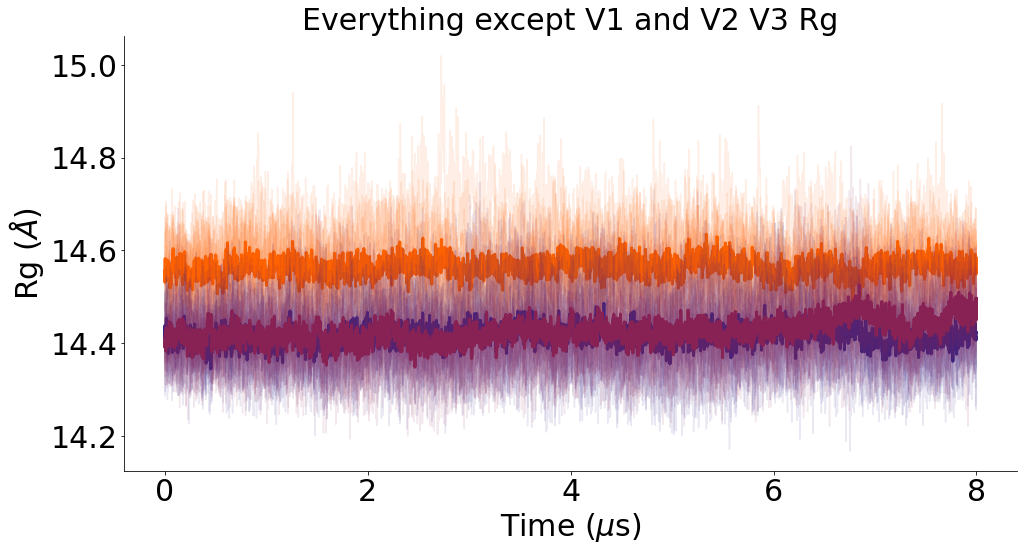

In [33]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False


figure(figsize = (16,8))
for i in range(len(all_body_rgs)):
    
    for j in range(len(all_body_rgs[i])):
        
        plot(all_body_rgs[i][j],color = colourScheme[i],alpha = 0.1)
        
    plot(mean(all_body_rgs[i],axis = 0),color = colourScheme[i],linewidth = 3)
        
        
xlabel("Time ($\mu$s)",fontsize = 30)
ylabel("Rg ($\AA$)",fontsize = 30)
title("Everything except V1 and V2 V3 Rg",fontsize = 30)
_=xticks([0,1000,2000,3000,4000],[0,2,4,6,8],fontsize = 30)
_=yticks(fontsize = 30)

In [5]:
def getRMSD(datasets):
    """ Takes data set and returns mean and standard error for each one """
    rmsds=[]
    sterrs=[]
    allrmsds=[]
    
    for i in range(len(datasets)):
        sub_rmsds=[]
        for j in range(len(datasets[i])):
            
                
            R = MDAnalysis.analysis.rms.RMSD(datasets[i][j])#,datasets[i][0])
                
            R.run()
            sub_rmsds.append(R.rmsd.T[2])
        allrmsds.append(sub_rmsds)
        rmsds.append(mean(sub_rmsds,axis = 0))
        sterrs.append(scipy.stats.sem(sub_rmsds))
        
    return rmsds,sterrs, allrmsds

allrmsds=getRMSD(bodys)[2]

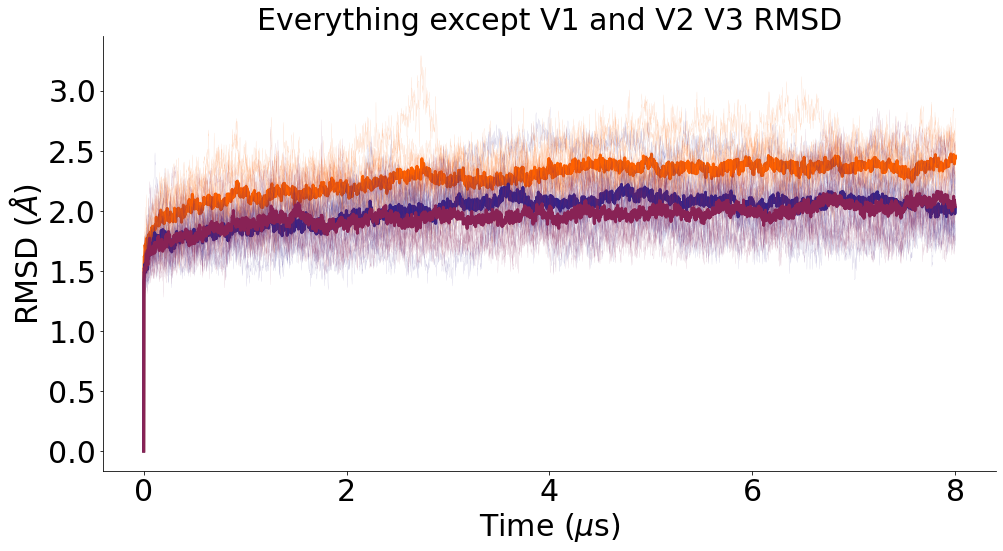

In [32]:
mpl.rcParams['axes.spines.right'] = False
mpl.rcParams['axes.spines.top'] = False


figure(figsize = (16,8))
for i in range(len(allrmsds)):
    plot(mean(allrmsds[i],axis = 0),color = colourScheme[i],linewidth = 3)
    for j in range(len(allrmsds[i])):
        
        plot(allrmsds[i][j],color = colourScheme[i],alpha = 0.5, linewidth = .1)
    #show()
    
xlabel("Time ($\mu$s)",fontsize = 30)
ylabel("RMSD ($\AA$)",fontsize = 30)
title("Everything except V1 and V2 V3 RMSD",fontsize = 30)
_=xticks([0,1000,2000,3000,4000],[0,2,4,6,8],fontsize = 30)
_=yticks(fontsize = 30)


#axhline(1.7)
#axhline(1.8)
#axhline(1.9)
#axhline(2.1)
#axhline(2.2)
#axhline(2.3)
#axhline(2.)
#
#ylim(1.5,2.7)

In [7]:
refPath_wt = "E:/projects/trim5Alpha/3_System_setup/alphafold_narval/systems/wt_hut5a/0/minimized.gro"
refU_wt = mda.Universe(refPath_wt).select_atoms("resid 290:491 and protein and not ("+combinedLoopString+")")

refPath_m = "E:/projects/trim5Alpha/3_System_setup/alphafold_narval/systems/r332p_hut5a/0/minimized.gro"
refU_m = mda.Universe(refPath_m).select_atoms("resid 290:491 and protein and not ("+combinedLoopString+")")

refPath_rh = "E:/projects/trim5Alpha/3_System_setup/alphafold_narval/systems/wt_rht5a/0/minimized.gro"
refU_rh = mda.Universe(refPath_rh).select_atoms("resid 291:495 and protein and not ("+combinedLoopString+")")

refs = [refU_rh,refU_wt,refU_m]


C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\topology\base.py:203: DeprecationWarning: `np.int` is a deprecated alias for the builtin `int`. To silence this warning, use `int` by itself. Doing this will not modify any behavior and is safe. When replacing `np.int`, you may wish to use e.g. `np.int64` or `np.int32` to specify the precision. If you wish to review your current use, check the release note link for additional information.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  residx = np.zeros_like(criteria[0], dtype=np.int)
C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: h

In [8]:
def getRMSD(datasets,refs):
    """ Takes data set and returns mean and standard error for each one """
    rmsds=[]
    sterrs=[]
    allrmsds=[]
    
    for i in range(len(datasets)):
        sub_rmsds=[]
        for j in range(len(datasets[i])):
            
                
            R = MDAnalysis.analysis.rms.RMSD(datasets[i][j],refs[i])
                
            R.run()
            sub_rmsds.append(R.rmsd.T[2])
        allrmsds.append(sub_rmsds)
        rmsds.append(mean(sub_rmsds,axis = 0))
        sterrs.append(scipy.stats.sem(sub_rmsds))
        
    return rmsds,sterrs, allrmsds
allrmsds=getRMSD(bodys[1:],refs[1:])[2]

SelectionError: Reference and trajectory atom selections do not contain the same number of atoms: N_ref=2791, N_traj=1833

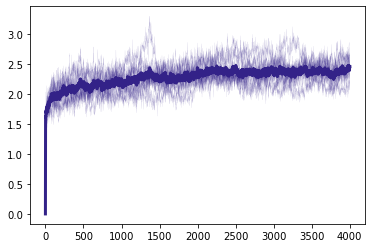

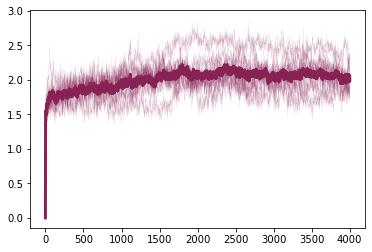

IndexError: list index out of range

In [16]:
for i in range(len(allrmsds)):
    plot(mean(allrmsds[i],axis = 0),color = colourScheme[i+1],linewidth = 3)
    for j in range(len(allrmsds[i])):
        
        plot(allrmsds[i][j],color = colourScheme[i+1],alpha = 0.5, linewidth = .1)
    show()

In [17]:
ca2 = contacts.Contacts(u, select=(sel_acidic, sel_basic),
                        refgroup=(acidic, basic),
                        radius=4.5,
                        method='radius_cut').run()

NameError: name 'contacts' is not defined

In [18]:
from MDAnalysis.analysis import contacts

In [19]:
ca1 = contacts.Contacts(systems[0][0],
                        select=(bodystrings[0][0],bodystrings[0][0]),
                        refgroup=(bodys[0][0],bodys[0][0]),
                        radius=3.5,
                        method='hard_cut').run()

C:\Users\Liam\anaconda3\lib\site-packages\MDAnalysis\core\selection.py:640: DeprecationWarning: `np.bool` is a deprecated alias for the builtin `bool`. To silence this warning, use `bool` by itself. Doing this will not modify any behavior and is safe. If you specifically wanted the numpy scalar type, use `np.bool_` here.
Deprecated in NumPy 1.20; for more details and guidance: https://numpy.org/devdocs/release/1.20.0-notes.html#deprecations
  mask = np.zeros(len(vals), dtype=np.bool)


KeyboardInterrupt: 

In [ ]:
allQ = []
for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        ca1 = contacts.Contacts(systems[i][j],
                        select=(bodystrings[i][j],bodystrings[i][j]),
                        refgroup=(bodys[i][j],bodys[i][j]),
                        radius=3.5,
                        method='hard_cut').run()
        save("Q_"+str(i)+"_"+str(j)+".npy",ca1.timeseries.T[1])
        sub.append(ca1.timeseries.T[1])
    allQ.append(sub)

In [20]:
#save("allQ_withoutv1v2v3.npy",allQ)
allQ=load("allQ_withoutv1v2v3.npy")

(0.42, 0.49)

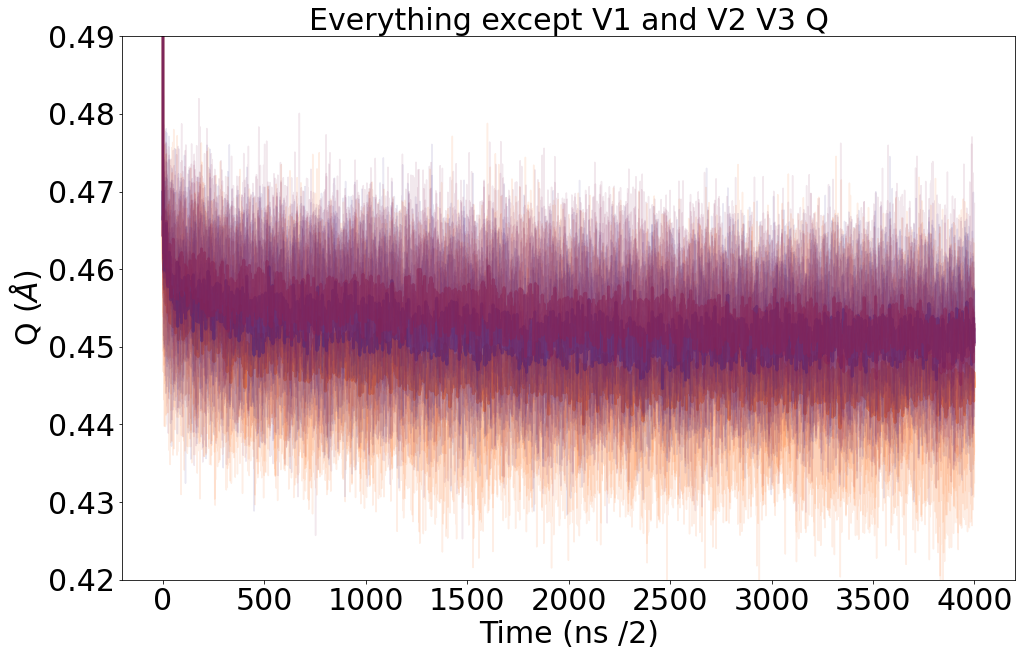

In [21]:
figure(figsize = (16,10))
for i in range(len(allQ)):
    
    for j in range(len(allQ[i])):
        
        plot(allQ[i][j],color = colourScheme[i],alpha = 0.1)
        
    plot(mean(allQ[i],axis = 0),color = colourScheme[i],linewidth = 3,alpha = 0.5)
        
        
xlabel("Time (ns /2)",fontsize = 30)
ylabel("Q ($\AA$)",fontsize = 30)
title("Everything except V1 and V2 V3 Q",fontsize = 30)
_=xticks(fontsize = 30)
_=yticks(fontsize = 30)


ylim(0.42,0.49)

In [22]:
allhbondarrays=[]

for i in range(len(systems)):
    sub=[]
    for j in range(len(systems[i])):
        
        results2 = load("raw_hbonds_cutoff3d5_"+str(i)+"_"+str(j)+"joblib.npy")
        sub.append(results2)
    allhbondarrays.append(sub)

In [23]:
hbondDFs=[]
for i in range(len(allhbondarrays)):
    sub=[]
    for j in range(len(allhbondarrays[i])):
        tdf=pd.DataFrame(allhbondarrays[i][j],columns=["frame","donorid","hid","acceptorid","distance","angle"])
        tu = systems[i][j]

        atomid_to_resid=dict(zip(tu.atoms.ids-1,tu.atoms.resids))

        tdf["donor_resid"] = tdf["donorid"].map(atomid_to_resid)
        tdf["acceptor_resid"] = tdf["acceptorid"].map(atomid_to_resid)

        resid_to_resname=dict(zip(tu.residues.resids,tu.residues.resnames))

        tdf["donor_resname"] = tdf["donor_resid"].map(resid_to_resname)
        tdf["acceptor_resname"] = tdf["acceptor_resid"].map(resid_to_resname)
        
        sub.append(tdf)
    hbondDFs.append(sub)

In [24]:
all_nhb=[]
for i in range(len(systems)):
    sub = []
    for j in range(len(systems[i])):
        tdf = hbondDFs[i][j]

        proteinprotein_tdf = tdf.dropna(axis = 0)
        proteinprotein_tdf

        nhb = []
        for t in range(int(max(proteinprotein_tdf.frame))):

            nhb.append(len(proteinprotein_tdf[proteinprotein_tdf["frame"] == t]))
            
        sub.append(nhb)
        
    all_nhb.append(sub)    

In [25]:
array(all_nhb).shape

(3, 9, 4000)

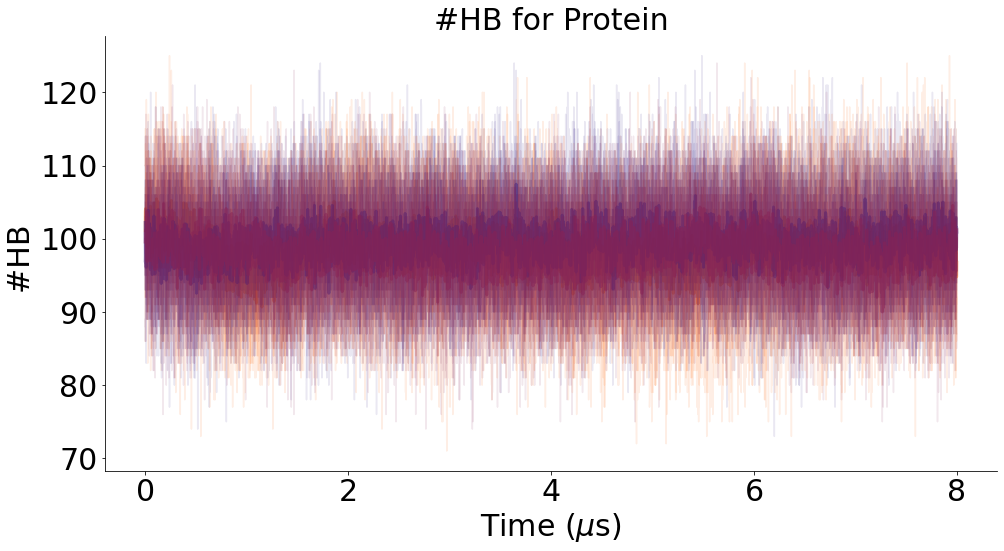

In [31]:
figure(figsize = (16,8))
for i in range(len(all_nhb)):
    
    for j in range(len(all_nhb[i])):
        
        plot(all_nhb[i][j],color = colourScheme[i],alpha = 0.1)
        
    plot(mean(all_nhb[i],axis = 0),color = colourScheme[i],linewidth = 3,alpha = 0.5)
        
        

xlabel("Time ($\mu$s)",fontsize = 30)

_=xticks([0,1000,2000,3000,4000],[0,2,4,6,8],fontsize = 30)
ylabel("#HB ",fontsize = 30)
title("#HB for Protein",fontsize = 30)
_=yticks(fontsize = 30)


